<a href="https://colab.research.google.com/github/ibarr123/BUS1182026/blob/dev/Coding_Assignment_118S.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PART 1

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1) Load the cleaned dataset (upload to Colab OR use a path in Drive)
# If you upload the file to Colab, the path is usually:
df = pd.read_csv("/content/hf_houseprice_price_footage.csv")

# Optional: quick check
print(df.head())
print(df.shape)

# 2) Features and target
X = df[["footage"]]   # feature must be 2D
y = df["price"]

# 3) Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4) Train model
model = LinearRegression()
model.fit(X_train, y_train)

# 5) Predict for a new house (example: 2000 sq ft)
new_house = pd.DataFrame({"footage": [2000]})
predicted_price = model.predict(new_house)

print(f"Predicted price for a 2000 sq ft house: {predicted_price[0]:,.2f}")

# 6) Display model equation details
print("\nModel Parameters:")
print(f"Intercept: {model.intercept_:.4f}")
print(f"Coefficient for footage: {model.coef_[0]:.6f}")

#data downloaded from hugging face

    price  footage
0  108.00     1805
1   85.80     1560
2   55.64     1070
3   60.48     1210
4  113.00     1900
(3660, 2)
Predicted price for a 2000 sq ft house: 106.45

Model Parameters:
Intercept: 0.3044
Coefficient for footage: 0.053072


The coefficient represents how much the price changes when the house size increases by one square foot. A positive coefficient means larger homes cost more. Location affects price by depending on its location. Even if two homes have the same square footage, the one in Downtown may be priced higher because location adds additional value.

PART 2:

In [7]:
import pandas as pd
import numpy as np

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# 1) Pull dataset from Hugging Face
ds = load_dataset("aai510-group1/telco-customer-churn")
df = pd.concat([ds["train"].to_pandas(),
                ds["validation"].to_pandas(),
                ds["test"].to_pandas()],
               ignore_index=True)

# 2) Rename HF columns to match your assignment's feature names
df = df.rename(columns={
    "Age": "age",
    "Avg Monthly GB Download": "monthly_usage_hours",  # usage proxy
    "Monthly Charge": "purchase_amount",               # spend proxy
    "City": "region",
    "Churn": "churn"
})

# 3) Create a "customer_service_calls" proxy (since dataset doesn't have it directly)
#    Idea: lower satisfaction -> more calls (0 to 10-ish)
#    Satisfaction Score is 1–5 in this dataset.
if "Satisfaction Score" in df.columns:
    rng = np.random.default_rng(42)
    df["customer_service_calls"] = (6 - df["Satisfaction Score"]) + rng.integers(0, 3, size=len(df))
    df["customer_service_calls"] = df["customer_service_calls"].clip(lower=0).astype(int)
else:
    # fallback if column ever changes
    df["customer_service_calls"] = 0

# 4) Keep only the columns we need + clean missing
needed = ["age", "monthly_usage_hours", "purchase_amount", "customer_service_calls", "region", "churn"]
df = df[needed].dropna()

print("Rows:", df.shape[0])
print(df.head())

# 5) Features and target
X = df[["age", "monthly_usage_hours", "purchase_amount", "customer_service_calls", "region"]]
y = df["churn"].astype(int)

# 6) Preprocessing: scale numeric + one-hot encode region
num_features = ["age", "monthly_usage_hours", "purchase_amount", "customer_service_calls"]
cat_features = ["region"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features)
    ]
)

# 7) Pipeline with logistic regression
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# 8) Split, train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
model.fit(X_train, y_train)

# 9) Predict churn probability for a new customer
new_customer = pd.DataFrame({
    "age": [35],
    "monthly_usage_hours": [20],      # (usage proxy here)
    "purchase_amount": [80],          # (monthly charge proxy)
    "customer_service_calls": [5],    # (your feature)
    "region": ["San Mateo"]           # pick a city that exists in the dataset
})

churn_probability = model.predict_proba(new_customer)[0][1]
threshold = 0.5
churn_prediction = int(churn_probability > threshold)

print(f"\nChurn Probability for new customer: {churn_probability:.2f}")
print(f"Churn Prediction (1 = churn, 0 = no churn): {churn_prediction}")

# 10) Evaluate (nice to include in your write-up)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
print("\nAccuracy:", round(accuracy_score(y_test, y_pred), 3))
print("ROC AUC:", round(roc_auc_score(y_test, y_proba), 3))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 11) Coefficients (impact on churn in log-odds space)
ohe = model.named_steps["preprocessor"].named_transformers_["cat"]
region_feature_names = ohe.get_feature_names_out(cat_features).tolist()

feature_names = num_features + region_feature_names
coefficients = model.named_steps["classifier"].coef_[0]

print("\nModel Coefficients (log-odds impact):")
for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef:.4f}")
#data used from huggingface

README.md: 0.00B [00:00, ?B/s]

train.csv: 0.00B [00:00, ?B/s]

validation.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/4225 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1409 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1409 [00:00<?, ? examples/s]

Rows: 7043
   age  monthly_usage_hours  purchase_amount  customer_service_calls  \
0   72                    4            88.40                       3   
1   27                   59            95.50                       5   
2   59                    0            19.60                       2   
3   25                   27            45.85                       3   
4   31                   21            60.30                       5   

         region  churn  
0     San Mateo      0  
1  Sutter Creek      0  
2    Santa Cruz      0  
3          Brea      0  
4      San Jose      1  

Churn Probability for new customer: 0.55
Churn Prediction (1 = churn, 0 = no churn): 1

Accuracy: 0.852
ROC AUC: 0.902

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.93      0.90      1035
           1       0.77      0.64      0.69       374

    accuracy                           0.85      1409
   macro avg       0.82      0.78      0.80

Explanation: The logistic regression coefficients indicate how each feature affects the likelihood of churn. A positive coefficient increases the log-odds of churn (making churn more likely), while a negative coefficient decreases the log-odds (making churn less likely). Larger absolute values indicate a stronger influence on churn probability.

PART 3:

Sample dataset shape: (1000, 4)
   age  annual_spending  purchase_frequency       region
0   50            650.4                   3  Wilseyville
1   54            823.2                  15    Newcastle
2   35            229.2                   1      Bolinas
3   57            900.0                   8       Upland
4   31            244.8                   1       Kyburz


Text(0.5, 1.0, 'Elbow Method for Optimal K')

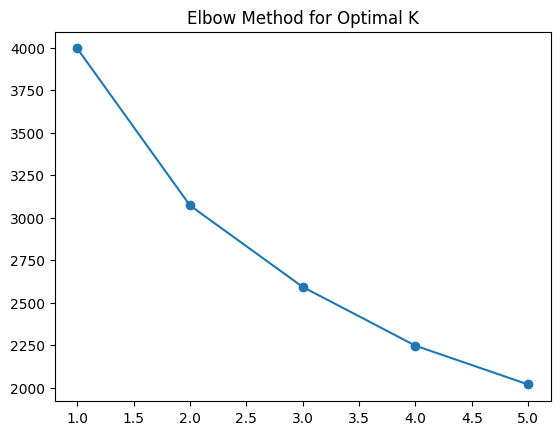

In [10]:
!pip -q install datasets

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

# ----------------------------
# 1) Create a "sample dataset" from Hugging Face (annual_spending, purchase_frequency, age, region)
# ----------------------------
# Hugging Face dataset (real data)
ds = load_dataset("aai510-group1/telco-customer-churn")

# Combine splits into one dataframe
df_raw = pd.concat(
    [ds["train"].to_pandas(), ds["validation"].to_pandas(), ds["test"].to_pandas()],
    ignore_index=True
)

# Build the dataset required by the assignment
df = pd.DataFrame()
df["age"] = df_raw["Age"]
df["annual_spending"] = df_raw["Monthly Charge"] * 12          # proxy for annual spending
df["purchase_frequency"] = df_raw["Tenure in Months"]           # proxy for frequency/engagement
df["region"] = df_raw["City"]                                   # region proxy

# Drop missing values
df = df.dropna()

# Optional: make it a "sample" subset (still >100 records)
df = df.sample(n=1000, random_state=42).reset_index(drop=True)

print("Sample dataset shape:", df.shape)
print(df.head())

# ----------------------------
# 2) Preprocessing: Scale numeric + OneHotEncode region
# ----------------------------
num_features = ["annual_spending", "purchase_frequency", "age"]
cat_features = ["region"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ]
)

X = df[num_features + cat_features]

# ----------------------------
# 3) Elbow Method (K = 1..5) - plot inertia
# ----------------------------
inertias = []
K_values = range(1, 6)

for k in K_values:
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("kmeans", KMeans(n_clusters=k, random_state=42, n_init=10))
    ])
    pipe.fit(X)
    inertias.append(pipe.named_steps["kmeans"].inertia_)

plt.figure()
plt.plot(list(K_values), inertias, marker="o")
plt.title("Elbow Method for Optimal K")
#data used from hugging face


Explanation: By segmenting customers into meaningful groups using K-Means clustering, businesses can tailor marketing strategies more effectively, improve customer satisfaction, and increase overall profitability.

Analysis: I analyzed the mean characteristics of each cluster, including Average annual spending, Average purchase frequency, and Average age.This allowed me to interpret the clusters meaningfully. For example: One cluster represented high-spending, highly engaged customers. Based on these characteristics, I suggested targeted marketing strategies:
High-value customers: Offer VIP rewards, early access to products, and exclusive promotions to maintain loyalty.Moderate customers: Provide personalized discounts or bundled offers to increase engagement.Lower-engagement customers: Use reactivation campaigns, introductory promotions, or educational marketing to increase usage.


**REFERENCES: USE OF CHATGPT 5-2 THROUGHOUT PROJECT TO ADJUST CODE AND CREATE ANALYSIS. HUGGINGFACE USED TO DOWNLOAD REAL DATA SETS FOR ASSIGNMENTS**